# Final Project

## Andres Dextre BIOE242

This project aims to use a previous data set for a massively multiplexed guide screen (Metsky, H. et al, 2022: https://doi.org/10.1038/s41587-022-01213-5). We will focus exclusively on the case where the gRNA and target RNA sequence are perfectly complementary.

### Load Libraries

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from nupack import *
from sklearn.model_selection import train_test_split
import re
import time
import textwrap
import pickle
import torch
import torch.nn as nn
from sklearn.model_selection import KFold
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from collections import Counter
from sklearn.model_selection import train_test_split
from scipy.stats import spearmanr
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from collections import Counter
from sklearn.ensemble import RandomForestRegressor

### Functions for encoding

In [2]:
my_model = Model(material='rna', celsius=37) # Predefined for NUPACK secondary structure prediction

normalizingScaler = StandardScaler() # Scaler for function

def reverse_complement(dna):
    # Input:
    # dna: String containing DNA sequence
    # Output:
    # Reverse complement converted to RNA
    complement = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C'}
    return "".join(complement[base] for base in reversed(dna))

# List all possible dinucleotides in RNA
bases = ['A', 'U', 'G', 'C']
all_possible = [b1 + b2 for b1 in bases for b2 in bases]

def one_hot_encode(seq):
    mapping = dict(zip("ACUG", range(4)))    
    seq2 = [mapping[i] for i in seq]
    return np.eye(4)[seq2].flatten()

def defineFeatures(guideSeq, targSeq):
    # Input:
    # guideSeq: RNA sequence of guide RNA
    # targSeq: RNA sequence of target RNA
    # Output:
    # List of handcrafted computed features
    
    GC = (targSeq.count('G') + targSeq.count('C')) / len(targSeq)
    Acount = targSeq.count('A')
    Ucount = targSeq.count('U')
    Gcount = targSeq.count('G')
    Ccount = targSeq.count('C')
    dinucleotides = [targSeq[i:i+2] for i in range(len(targSeq)-1)]
    counts = Counter(dinucleotides)
    dinucleotide_counts = [counts[dinucleotide] for dinucleotide in all_possible]
    mfe_structures = mfe(strands=targSeq, model=my_model)
    targMFE = mfe_structures[0].energy
    targStructure = mfe_structures[0].structure
    targBasePaired = str(targStructure).count('(') * 2 / len(targSeq)
    hybrMFE = structure_energy(strands=[guideSeq, targSeq], structure='((((((((((((((((((((((((((((+....................))))))))))))))))))))))))))))....................', model = my_model)
    hybrProb = structure_probability(strands=[guideSeq, targSeq], structure='((((((((((((((((((((((((((((+....................))))))))))))))))))))))))))))....................', model = my_model)
    return [GC, Acount, Ucount, Gcount, Ccount, targMFE, targBasePaired, hybrMFE, hybrProb] + dinucleotide_counts

### Load encoded dataset



In [3]:
FullDataSet = pd.read_csv("CombinedEncodingFullDataSet.csv")
FullDataSet["Handcrafted"] = FullDataSet["Handcrafted"].apply(lambda x: eval(x))
FullDataSet["OneHotEncode"] = FullDataSet["OneHotEncode"].apply(lambda x: eval(x.replace(".",",")))
FullDataSet = FullDataSet.reset_index()
FullDataSet.head()

,index,Unnamed: 0,TargetSequence,Handcrafted,OneHotEncode,out_logk_measurement
0,0,0,CUGAAAACAAGCGCACCUCCAGAGACAAAUAAUCUCCAUGACUAGU...,"[0.4411764705882353, 26, 12, 12, 18, -9.722476...","[0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, ...",-0.932544
1,1,1,CUGAAAACAAGCGCACCUCCAGAGACAAAUAAUCUCCAUGACUAGU...,"[0.4411764705882353, 26, 12, 12, 18, -9.722476...","[0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, ...",-0.919821
2,2,2,CUGAAAACAAGCGCACCUCCAGAGACAAAUAAUCUCCAUGACUAGU...,"[0.4411764705882353, 26, 12, 12, 18, -9.722476...","[0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, ...",-0.844260
3,3,3,CUGAAAACAAGCGCACCUCCAGAGACAAAUAAUCUCCAUGACUAGU...,"[0.4411764705882353, 26, 12, 12, 18, -9.722476...","[0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, ...",-1.112596
4,4,4,CUGAAAACAAGCGCACCUCCAGAGACAAAUAAUCUCCAUGACUAGU...,"[0.4411764705882353, 26, 12, 12, 18, -9.722476...","[0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, ...",-0.777155


### Prepara dataset

In [4]:
normalizingScaler = StandardScaler()
def SaveFeatures(df):
    # Input:
    # df: Dataframe
    # Output:
    # OneHotFeatures: One hot encoded dataset
    # HandcraftedNormalized: Normalized full training
    # df["out_logk_measurement"].values: y-output values
    
    # Save matrix of One-Hot-Features
    OneHotFeatures = np.stack(df["OneHotEncode"].values)

    # Save matrix of Handcrafted features and normalize
    HandcraftedFeatures = np.stack(df["Handcrafted"].values)
    HandcraftedNormalized = normalizingScaler.fit_transform(HandcraftedFeatures)
    
    return OneHotFeatures, HandcraftedNormalized, df["out_logk_measurement"].values

In [5]:
train, test = train_test_split(FullDataSet, test_size=0.20, random_state=25) # Split into train dataframe

# Save X and y values for each split in both One-Hot and feature engineered encoding
X_1H_train, X_HC_train, y_train = SaveFeatures(train)
X_1H_test, X_HC_test, y_test = SaveFeatures(test)
X_1H_train_CNN = X_1H_train.reshape(-1, 1, 68, 4)
X_1H_test_CNN = X_1H_test.reshape(-1, 1, 68, 4)

### Functions for random forest classification

In [11]:
def RF_KFold(X, y, k, n_estimators, max_depth):
    
    kf = KFold(n_splits=k, shuffle=True)
    
    train_acc_list = []
    val_acc_list = []
    
    for i, (train_index, val_index) in enumerate(kf.split(X)):
        
        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y[train_index], y[val_index]
        
        rfModel = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth)
        rfModel.fit(X_train, y_train)
        y_train_pred = rfModel.predict(X_train)
        y_pred = rfModel.predict(X_val)
        
        train_acc, pval = spearmanr(y_train, y_train_pred)
        val_acc, pval = spearmanr(y_val, y_pred)
                
        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)
    
    return train_acc_list, val_acc_list

def RF_KFold_Save(X, y, k, n_estimators, max_depth):
    
    kf = KFold(n_splits=k, shuffle=True)
    
    train_acc_list = []
    val_acc_list = []
    
    rfModels = []
    
    for i, (train_index, val_index) in enumerate(kf.split(X)):
        
        print(f"Fold {i}:")
        
        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y[train_index], y[val_index]
        
        rfModel = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth)
        rfModel.fit(X_train, y_train)
        y_train_pred = rfModel.predict(X_train)
        y_pred = rfModel.predict(X_val)
        
        train_acc, pval = spearmanr(y_train, y_train_pred)
        val_acc, pval = spearmanr(y_val, y_pred)
                
        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)
        
        print(f"Training accuracy: {train_acc}")
        print(f"Test accuracy: {val_acc}")
        
        rfModels.append(rfModel)
    
    return rfModels

In [34]:
rfNumTrees = []
rfTrainAcc = []
rfValAcc = []

for i in range(2, 40, 4):
    rfTAc, rfVAc = RF_KFold(X_HC_train,y_train, 5, 20, i)
    print(i)
    rfNumTrees.append(i)
    rfTrainAcc.append(rfTAc)
    rfValAcc.append(rfVAc)

2
6
10
14
18
22
26
30
34
38


Text(0.5, 0, 'Tree depth')

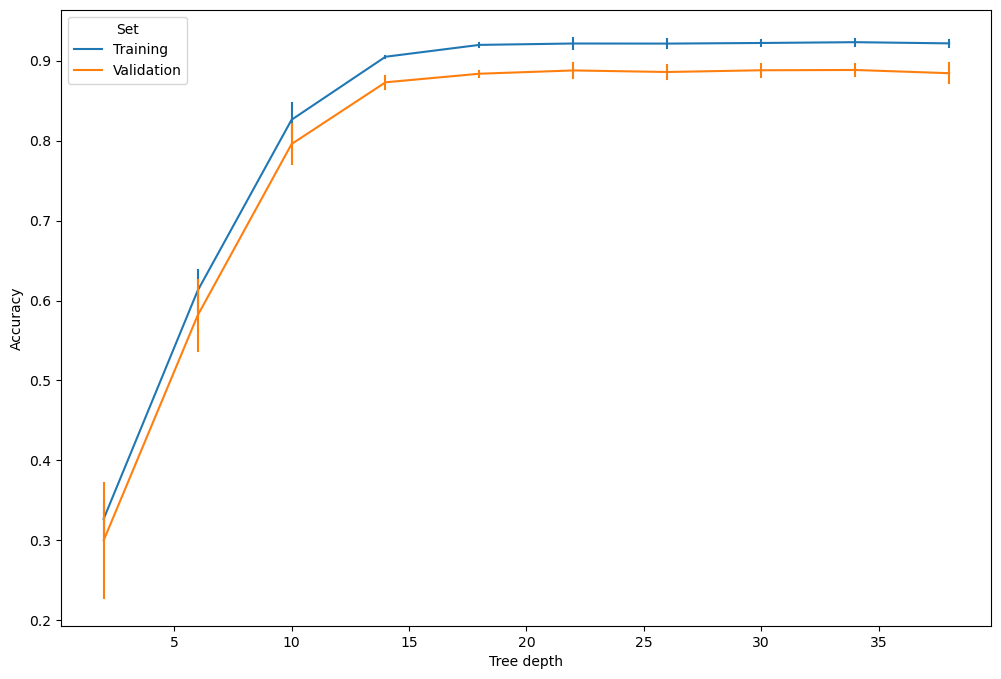

In [35]:
trainingRFDF = pd.DataFrame(rfTrainAcc, columns = ["0","1", "2","3","4"])
trainingRFDF["Number of trees"] = rfNumTrees
trainingRFDF["Set"] = "Training"
valRFDF = pd.DataFrame(rfValAcc, columns = ["0","1", "2","3","4"])
valRFDF["Number of trees"] = rfNumTrees
valRFDF["Set"] = "Validation"
completeRFSet = pd.concat([trainingRFDF.melt(value_vars = ["0","1","2","3","4"], var_name = "Fold", value_name = "Accuracy", id_vars=["Number of trees","Set"]),valRFDF.melt(value_vars = ["0","1","2","3","4"], var_name = "Fold", value_name = "Accuracy", id_vars=["Number of trees","Set"])])
completeRFSet = completeRFSet.reset_index()
plt.figure(figsize=(12,8))
sns.lineplot(data = completeRFSet, x = "Number of trees", hue = "Set", y = "Accuracy", err_style="bars", errorbar="sd")
plt.xlabel("Tree depth")

In [14]:
rfFinals= RF_KFold_Save(X_HC_train,y_train, 5, 20, None)

Fold 0:
Training accuracy: 0.9236011561212732
Test accuracy: 0.8817458664627437
Fold 1:
Training accuracy: 0.9249060160986807
Test accuracy: 0.8892109638667747
Fold 2:
Training accuracy: 0.9235690863592952
Test accuracy: 0.893698296393605
Fold 3:
Training accuracy: 0.9179040940341899
Test accuracy: 0.8825504624105027
Fold 4:
Training accuracy: 0.9180495020356242
Test accuracy: 0.8891850376780412


/tmp/ipykernel_1946/1471835084.py:8: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(labels)


[Text(0, 0, 'Secondary\nstructure\nfree\nenergy'),
 Text(1, 0, 'Hybridizat\nion probab\nility'),
 Text(2, 0, 'Hybridizat\nion free\nenergy'),
 Text(3, 0, 'UG'),
 Text(4, 0, 'Number of\nGs'),
 Text(5, 0, 'AC'),
 Text(6, 0, 'GA'),
 Text(7, 0, 'GG'),
 Text(8, 0, 'GU'),
 Text(9, 0, 'Secondary\nstructure\npairing'),
 Text(10, 0, 'Number of\nAs'),
 Text(11, 0, 'Number of\nUs'),
 Text(12, 0, 'AG'),
 Text(13, 0, 'GC'),
 Text(14, 0, 'GC%'),
 Text(15, 0, 'Number of\nCs'),
 Text(16, 0, 'UA'),
 Text(17, 0, 'CA'),
 Text(18, 0, 'CU'),
 Text(19, 0, 'AU'),
 Text(20, 0, 'AA'),
 Text(21, 0, 'UC'),
 Text(22, 0, 'CC'),
 Text(23, 0, 'CG'),
 Text(24, 0, 'UU')]

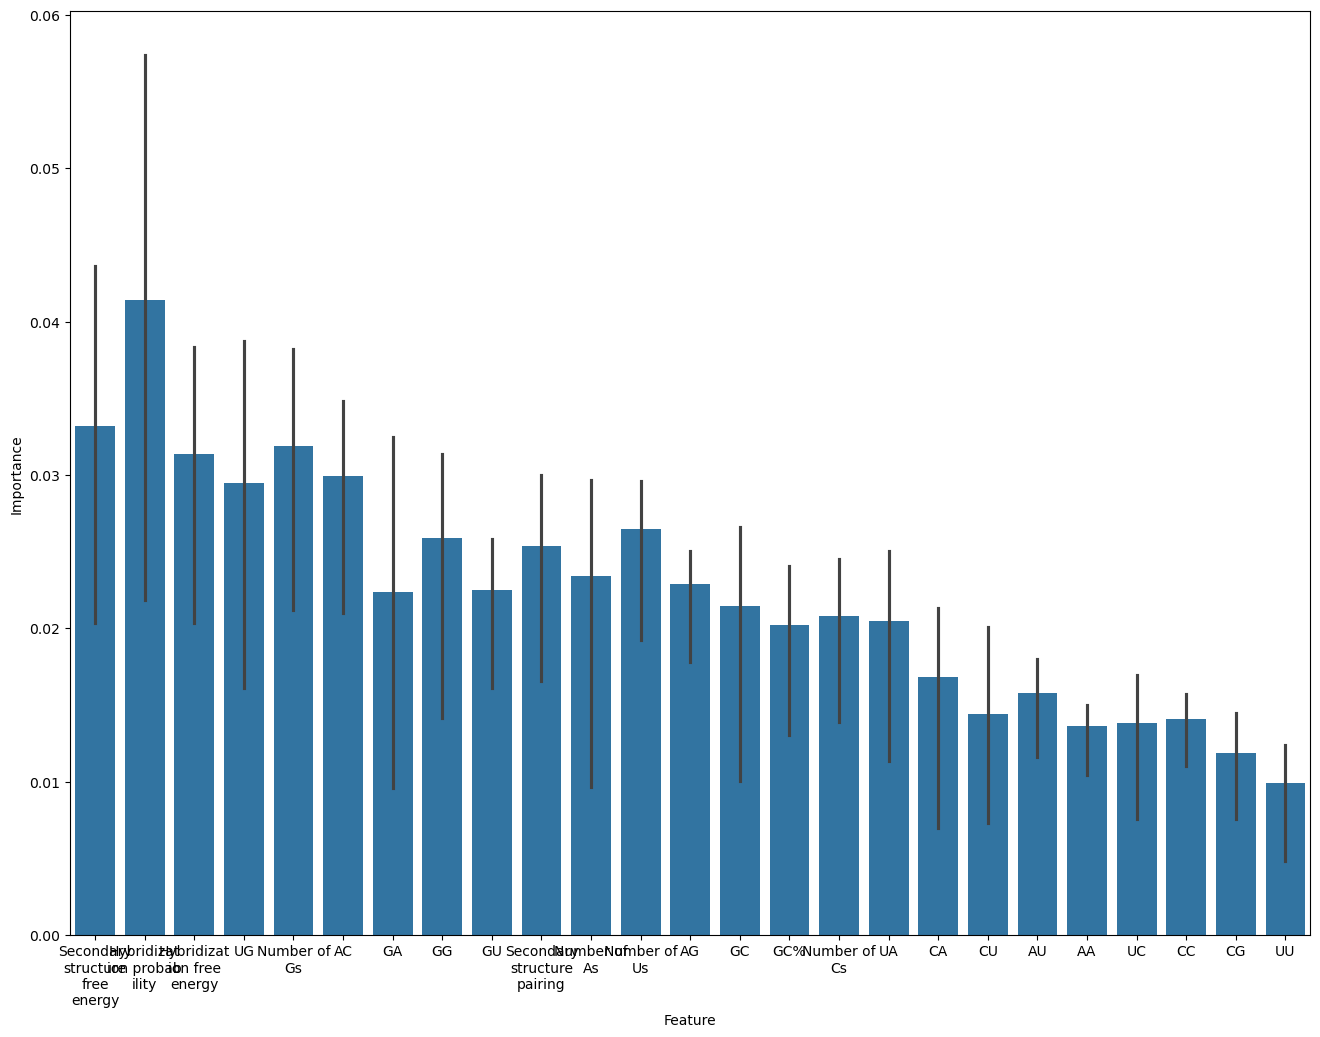

In [49]:
bases = ['A', 'U', 'G', 'C']
all_possible = [b1 + b2 for b1 in bases for b2 in bases]
columns = ["GC%", "Number of As", "Number of Us", "Number of Gs", "Number of Cs", "Secondary structure free energy", "Secondary structure pairing", "Hybridization free energy", "Hybridization probability"]+all_possible
plt.figure(figsize=(16, 12))
ax = sns.barplot(data = pd.melt(pd.DataFrame(np.array([tree.feature_importances_ for tree in rfFinals[4].estimators_]), columns = columns), var_name = "Feature", value_name="Importance").sort_values('Importance', ascending=False), x = "Feature", y = "Importance", estimator="std")
max_width = 10 # Adjust as needed
labels = [textwrap.fill(label.get_text(), max_width) for label in ax.get_xticklabels()]
ax.set_xticklabels(labels)

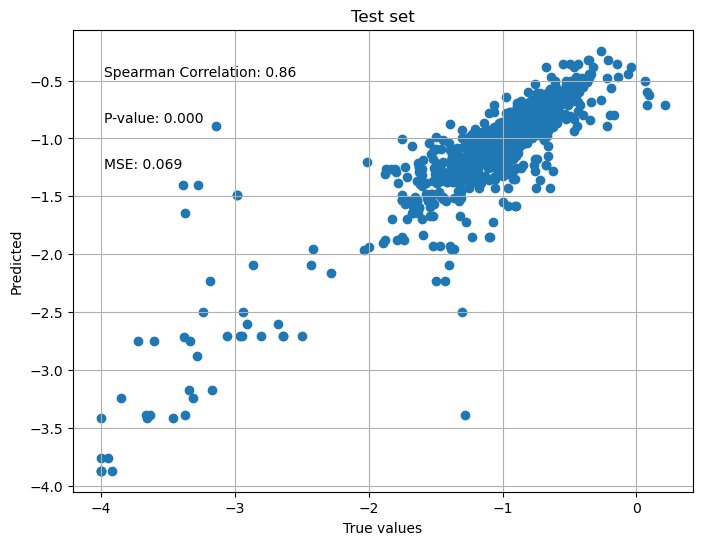

In [236]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rfFinals[4].predict(X_HC_test))
plt.xlabel("True values")
plt.ylabel("Predicted")
plt.title("Test set")

# Calculate Spearman correlation and p-value
correlation, p_value = spearmanr(y_test, rfFinals[4].predict(X_HC_test))
mse = mean_squared_error(y_test, rfFinals[4].predict(X_HC_test))

plt.text(
    0.05,
    0.9,
    f"Spearman Correlation: {correlation:.2f}",
    transform=plt.gca().transAxes,
)
plt.text(
    0.05,
    0.8,
    f"P-value: {p_value:.3f}",
    transform=plt.gca().transAxes,
)

plt.text(
    0.05,
    0.7,
    f"MSE: {mse:.3f}",
    transform=plt.gca().transAxes,
)



# Show the plot
plt.grid(True)
plt.show()

### Functions for neural network testing

In [4]:
class Cas13DataSet():

    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx].view(1)

def timeit(f):

    def timed(*args, **kw):

        ts = time.time()
        result = f(*args, **kw)
        te = time.time()

        print(f'func: {f.__name__} took: {te-ts:.4f} sec')
        return result

    return timed

class Trainer:
    
    def __init__(self, model, opt_method, learning_rate, batch_size, epoch, l2):
        self.model = model
        if opt_method == "sgdm":
            self.optimizer = torch.optim.SGD(model.parameters(), learning_rate, momentum=0.9)
        elif opt_method == "adam":
            self.optimizer = torch.optim.Adam(model.parameters(), learning_rate, weight_decay=l2)
        else:
            raise NotImplementedError("This optimization is not supported")
        
        self.epoch = epoch
        self.batch_size = batch_size
    
    def train(self, train_data, val_data, early_stop=True, verbose=True, draw_curve=True):
        train_loader = DataLoader(train_data, batch_size=self.batch_size, shuffle=True)
        
        train_loss_list, train_acc_list = [], []
        val_loss_list, val_acc_list = [], []
        weights = self.model.state_dict()
        lowest_val_loss = np.inf
        loss_func = nn.MSELoss()
        for n in tqdm(range(self.epoch), leave=False):
            self.model.train()
            for X_batch, y_batch in train_loader:
                y_pred = self.model(X_batch)
                y_pred = torch.clamp(y_pred, min=-1e5, max=1e6)
                batch_loss = loss_func(y_pred, y_batch)
                
                self.optimizer.zero_grad()
                batch_loss.backward()
                self.optimizer.step()
                
            train_loss, train_acc = self.evaluate(train_data)
            train_loss_list.append(train_loss)
            train_acc_list.append(train_acc)
            
            val_loss, val_acc = self.evaluate(val_data)
            val_loss_list.append(val_loss)
            val_acc_list.append(val_acc)
            
            if early_stop:
                if val_loss < lowest_val_loss:
                    lowest_val_loss = val_loss
                    weights = self.model.state_dict().copy()
        if draw_curve:
            x_axis = np.arange(self.epoch)
            fig, axes = plt.subplots(1, 2, figsize=(10, 4))
            axes[0].plot(x_axis, train_loss_list, label="Train")
            axes[0].plot(x_axis, val_loss_list, label="Validation")
            axes[0].set_title("Loss")
            axes[0].legend()
            axes[1].plot(x_axis, train_acc_list, label='Train')
            axes[1].plot(x_axis, val_acc_list, label='Validation')
            axes[1].set_title("Accuracy")
            axes[1].legend()
        
        if early_stop:
            self.model.load_state_dict(weights)
        
        return {
            "train_loss_list": train_loss_list,
            "train_acc_list": train_acc_list,
            "val_loss_list": val_loss_list,
            "val_acc_list": val_acc_list,
        }
    
    def evaluate(self, data, print_acc=False):
        self.model.eval()
        loader = DataLoader(data, batch_size=self.batch_size, shuffle=True)
        loss_func = nn.MSELoss()
        acc, loss = 0.0, 0.0
        for X_batch, y_batch in loader:
            with torch.no_grad():
                batch_importance = y_batch.shape[0] / len(data)
                y_pred = self.model(X_batch)
                y_pred = torch.clamp(y_pred, min=-1e5, max=1e6)
                batch_loss = loss_func(y_pred, y_batch)
                batch_acc, pval = spearmanr(y_batch, y_pred)
                batch_acc = torch.tensor(batch_acc, dtype = torch.float) # Use spearman correlation to evaluate accuracy
                acc += batch_acc.detach().cpu().item() * batch_importance
                loss += batch_loss.detach().cpu().item() * batch_importance
        if print_acc:
            print(f"Accuracy: {acc:.3f}")
        return loss, acc

### K-fold cross validation

In [5]:
def KFoldCrossValidation(
    model_class, k, 
    X_train, y_train, X_test, y_test, 
    opt_method='adam', learning_rate=2e-3, batch_size=128, epoch=50, l2=0.0,
    early_break=False,
    **model_args
):
    test_data = Cas13DataSet(torch.tensor(X_test, dtype=torch.float), torch.tensor(y_test, dtype=torch.float))
    kf = KFold(n_splits=k, shuffle=True)
    train_acc_list, test_acc_list = [], []
    best_model_state = None
    best_test_acc = None
    for i, (train_index, val_index) in enumerate(kf.split(X_train)):
        print(f"Fold {i}:")

        train_data = Cas13DataSet(torch.tensor(X_train[train_index], dtype=torch.float), torch.tensor(y_train[train_index], dtype=torch.float))
        val_data = Cas13DataSet(torch.tensor(X_train[val_index], dtype = torch.float), torch.tensor(y_train[val_index], dtype = torch.float))
        
        model = model_class(X_train.shape[1])
        
        trainer = Trainer(model, opt_method, learning_rate, batch_size, epoch, l2)
        res = trainer.train(train_data, val_data, draw_curve = True)
        train_acc_best = res['train_acc_list'][np.argmin(res['val_loss_list'])]
        test_loss, test_acc = trainer.evaluate(val_data)
        
        train_acc_list.append(train_acc_best)
        test_acc_list.append(test_acc)
        
        print(f"Training accuracy: {train_acc_best}")
        print(f"Test accuracy: {test_acc}")
        
        if early_break:
            break
    
    if not early_break:
        print("Final results:")
        print(f"Training accuracy: {np.mean(train_acc_list)}+/-{np.std(train_acc_list)}")
        print(f"Test accuracy: {np.mean(test_acc_list)}+/-{np.std(test_acc_list)}")

def KFoldCrossValidationSaveRes(
    model_class, k, 
    X_train, y_train, X_test, y_test, 
    opt_method='adam', learning_rate=2e-3, batch_size=128, epoch=50, l2=0.0,
    early_break=False,
    **model_args
):
    test_data = Cas13DataSet(torch.tensor(X_test, dtype=torch.float), torch.tensor(y_test, dtype=torch.float))
    kf = KFold(n_splits=k, shuffle=True)
    train_acc_list, test_acc_list = [], []
    best_model_state = None
    best_test_acc = None
    for i, (train_index, val_index) in enumerate(kf.split(X_train)):
        print(f"Fold {i}:")

        train_data = Cas13DataSet(torch.tensor(X_train[train_index], dtype=torch.float), torch.tensor(y_train[train_index], dtype=torch.float))
        val_data = Cas13DataSet(torch.tensor(X_train[val_index], dtype = torch.float), torch.tensor(y_train[val_index], dtype = torch.float))
        
        model = model_class(X_train.shape[1])
        
        trainer = Trainer(model, opt_method, learning_rate, batch_size, epoch, l2)
        res = trainer.train(train_data, val_data, draw_curve = False)
        train_acc_best = res['train_acc_list'][np.argmin(res['val_loss_list'])]
        test_loss, test_acc = trainer.evaluate(val_data)
        
        train_acc_list.append(train_acc_best)
        test_acc_list.append(test_acc)
        
        if early_break:
            break
    
    return train_acc_list, test_acc_list

### Architectures to test

In [10]:
class Net5_5_1(nn.Module):
    def __init__(self,input_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 5)
        self.fc2 = nn.Linear(5, 5)
        self.fc3 = nn.Linear(5,1)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x
    
class LinearCNN(nn.Module):
       
    def __init__(self, in_cs=1):
        super().__init__()
        self.conv = nn.ModuleList([
            nn.Conv1d(in_channels = 1, out_channels=3, kernel_size=4, stride=4, padding=0),
        ])
        self.activation = nn.ReLU()
        self.fc = nn.ModuleList([
            nn.Linear(204, 5), nn.Linear(5,1)])
    
    def forward(self, x):
        if x.ndim == 2:
            x = x.unsqueeze(1)
            
        for i in range(1):
            x = self.conv[i](x)
        x = nn.Flatten()(x)
        x = self.activation(self.fc[0](x))
        x = self.fc[1](x)
        
        return x
    
class DoubleLinearCNN(nn.Module):
       
    def __init__(self, in_cs=1):
        super().__init__()
        self.conv = nn.ModuleList([
            nn.Conv1d(in_channels=1, out_channels=3, kernel_size=4, stride=4, padding=0),
            nn.Conv1d(in_channels=3, out_channels=3, kernel_size=4, stride=4, padding=0)
        ])
        self.pool = nn.AvgPool1d(kernel_size=4)
        self.activation = nn.ReLU()
        self.fc = nn.ModuleList([
            nn.Linear(51, 5), nn.Linear(5,1)])
    
    def forward(self, x):
        if x.ndim == 2:
            x = x.unsqueeze(1)
            
        for i in range(2):
            x = self.conv[i](x)
        x = nn.Flatten()(x)
        x = self.activation(self.fc[0](x))
        x = self.fc[1](x)
        
        return x
        
class BasicCNN_3Filters(nn.Module):
       
    def __init__(self, in_channels=1):
        super().__init__()
        self.conv = nn.ModuleList([
            nn.Conv2d(in_channels, out_channels=3, kernel_size=4, stride=4, padding=0),
        ])
        self.activation = nn.ReLU()
        self.fc = nn.ModuleList([
            nn.Linear(51, 5), nn.Linear(5,1)])
    
    def forward(self, x):
        for i in range(1):
            x = self.conv[i](x)
        x = nn.Flatten()(x)
        x = self.activation(self.fc[0](x))
        x = self.fc[1](x)
        
        return x

### Testing different architectures

#### Comparing One Hot Encoding vs Engineered Features

In [12]:
net551_EF_train, net551_EF_val = KFoldCrossValidationSaveRes(Net5_5_1, 5, 
    X_HC_train, y_train, X_HC_test, y_test, 
    opt_method='adam', learning_rate=1e-3, batch_size=100, epoch=100, l2=0,
    early_break=False)
linearCNN_1H_train, linearCNN_1H_val = KFoldCrossValidationSaveRes(LinearCNN, 5, 
    X_1H_train, y_train, X_1H_test, y_test, 
    opt_method='adam', learning_rate=1e-3, batch_size=100, epoch=100, l2=0,
    early_break=False)
twoLinearCNN_1H_train, twoLinearCNN_1H_val = KFoldCrossValidationSaveRes(DoubleLinearCNN, 5, 
    X_1H_train, y_train, X_1H_test, y_test, 
    opt_method='adam', learning_rate=1e-3, batch_size=100, epoch=100, l2=0,
    early_break=False)
doubleCNN_3filters_1H_train, doubleCNN_3filters_1H_val = KFoldCrossValidationSaveRes(BasicCNN_3Filters, 5, 
    X_1H_train_CNN, y_train, X_1H_test_CNN, y_test, 
    opt_method='adam', learning_rate=1e-3, batch_size=100, epoch=100, l2=0,
    early_break=False)

Fold 0:


Fold 1:


Fold 2:


Fold 3:


Fold 4:


...

Fold 0:


Fold 1:


Fold 2:


Fold 3:


Fold 4:


<Axes: xlabel='Architecture', ylabel='Accuracy'>

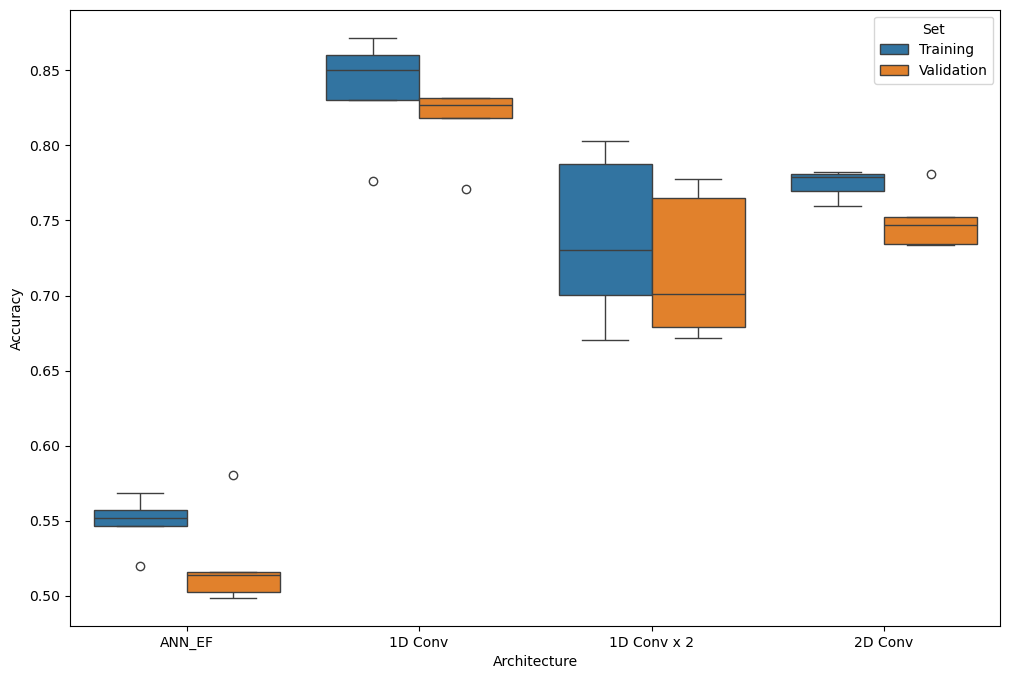

In [14]:
trainingArchDF = pd.DataFrame([net551_EF_train, linearCNN_1H_train, twoLinearCNN_1H_train, doubleCNN_3filters_1H_train], columns = ["0","1", "2","3","4"])
trainingArchDF["Architecture"] = ["ANN_EF", "1D Conv", "1D Conv x 2", "2D Conv"]
trainingArchDF["Set"] = "Training"
valArchDF = pd.DataFrame([net551_EF_val, linearCNN_1H_val, twoLinearCNN_1H_val, doubleCNN_3filters_1H_val], columns = ["0","1", "2","3","4"])
valArchDF["Architecture"] = ["ANN_EF", "1D Conv", "1D Conv x 2", "2D Conv"]
valArchDF["Set"] = "Validation"
completeArchitectureSet = pd.concat([trainingArchDF.melt(value_vars = ["0","1","2","3","4"], var_name = "Fold", value_name = "Accuracy", id_vars=["Architecture","Set"]),valArchDF.melt(value_vars = ["0","1","2","3","4"], var_name = "Fold", value_name = "Accuracy", id_vars=["Architecture","Set"])])
completeArchitectureSet = completeArchitectureSet.reset_index()
plt.figure(figsize=(12,8))
sns.boxplot(data = completeArchitectureSet, x = "Architecture", hue = "Set", y = "Accuracy", dodge = "True")

### Refining architectures

In [15]:
class LinearCNN_1Filters(nn.Module):
       
    def __init__(self, in_cs=1):
        super().__init__()
        self.conv = nn.ModuleList([
            nn.Conv1d(in_channels = 1, out_channels=1, kernel_size=4, stride=4, padding=0),
        ])
        self.activation = nn.ReLU()
        self.fc = nn.ModuleList([
            nn.Linear(68, 5), nn.Linear(5,1)])
    
    def forward(self, x):
        if x.ndim == 2:
            x = x.unsqueeze(1)
            
        for i in range(1):
            x = self.conv[i](x)
        x = nn.Flatten()(x)
        x = self.activation(self.fc[0](x))
        x = self.fc[1](x)
        
        return x

class LinearCNN_2Filters(nn.Module):
       
    def __init__(self, in_cs=1):
        super().__init__()
        self.conv = nn.ModuleList([
            nn.Conv1d(in_channels = 1, out_channels=2, kernel_size=4, stride=4, padding=0),
        ])
        self.activation = nn.ReLU()
        self.fc = nn.ModuleList([
            nn.Linear(136, 5), nn.Linear(5,1)])
    
    def forward(self, x):
        if x.ndim == 2:
            x = x.unsqueeze(1)
            
        for i in range(1):
            x = self.conv[i](x)
        x = nn.Flatten()(x)
        x = self.activation(self.fc[0](x))
        x = self.fc[1](x)
        
        return x

class BasicCNN_1Filters(nn.Module):
       
    def __init__(self, in_channels=1):
        super().__init__()
        self.conv = nn.ModuleList([
            nn.Conv2d(in_channels, out_channels=1, kernel_size=4, stride=4, padding=0),
        ])
        self.activation = nn.ReLU()
        self.fc = nn.ModuleList([
            nn.Linear(17, 5), nn.Linear(5,1)])
    
    def forward(self, x):
        for i in range(1):
            x = self.conv[i](x)
        x = nn.Flatten()(x)
        x = self.activation(self.fc[0](x))
        x = self.fc[1](x)
        
        return x

class BasicCNN_2Filters(nn.Module):
       
    def __init__(self, in_channels=1):
        super().__init__()
        self.conv = nn.ModuleList([
            nn.Conv2d(in_channels, out_channels=2, kernel_size=4, stride=4, padding=0),
        ])
        self.activation = nn.ReLU()
        self.fc = nn.ModuleList([
            nn.Linear(34, 5), nn.Linear(5,1)])
    
    def forward(self, x):
        for i in range(1):
            x = self.conv[i](x)
        x = nn.Flatten()(x)
        x = self.activation(self.fc[0](x))
        x = self.fc[1](x)
        
        return x

In [16]:
linearCNN_1filters_1H_train, linearCNN_1filters_1H_val = KFoldCrossValidationSaveRes(LinearCNN_1Filters, 5, 
    X_1H_train, y_train, X_1H_test, y_test, 
    opt_method='adam', learning_rate=1e-3, batch_size=100, epoch=100, l2=0,
    early_break=False)
linearCNN_2filters_1H_train, linearCNN_2filters_1H_val = KFoldCrossValidationSaveRes(LinearCNN_2Filters, 5, 
    X_1H_train, y_train, X_1H_test, y_test, 
    opt_method='adam', learning_rate=1e-3, batch_size=100, epoch=100, l2=0,
    early_break=False)
doubleCNN_1filters_1H_train, doubleCNN_1filters_1H_val = KFoldCrossValidationSaveRes(BasicCNN_1Filters, 5, 
    X_1H_train_CNN, y_train, X_1H_test_CNN, y_test, 
    opt_method='adam', learning_rate=1e-3, batch_size=100, epoch=100, l2=0,
    early_break=False)
doubleCNN_2filters_1H_train, doubleCNN_2filters_1H_val = KFoldCrossValidationSaveRes(BasicCNN_2Filters, 5, 
    X_1H_train_CNN, y_train, X_1H_test_CNN, y_test, 
    opt_method='adam', learning_rate=1e-3, batch_size=100, epoch=100, l2=0,
    early_break=False)

Fold 0:


Fold 1:


Fold 2:


Fold 3:


Fold 4:


...

Fold 0:


Fold 1:


Fold 2:


Fold 3:


Fold 4:


<Axes: xlabel='Architecture', ylabel='Accuracy'>

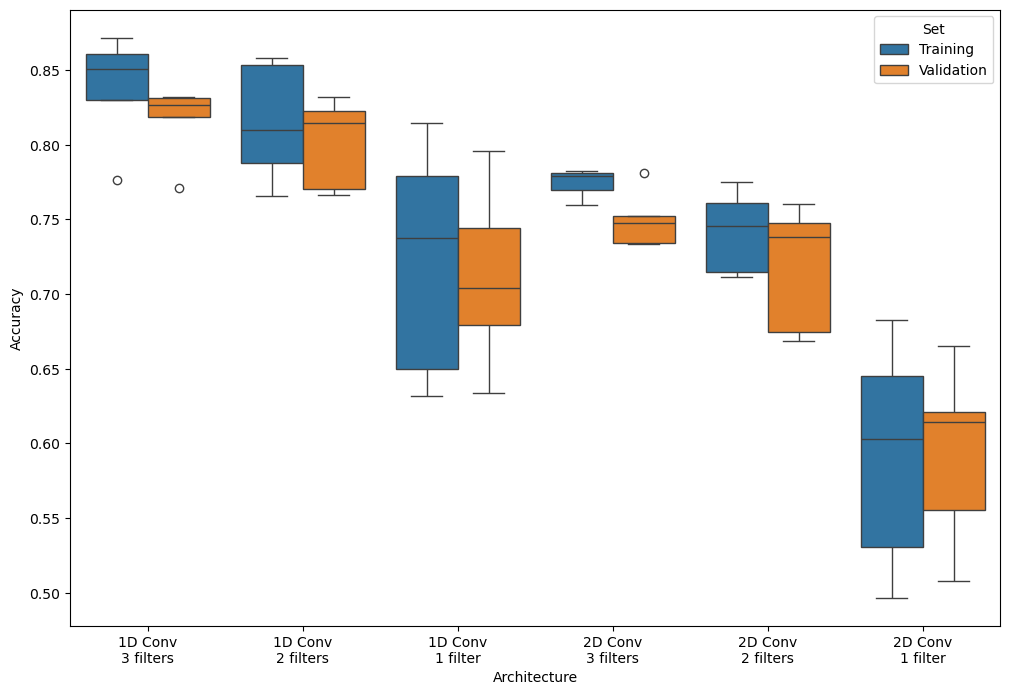

In [17]:
trainingFineArchDF = pd.DataFrame([linearCNN_1H_train, linearCNN_2filters_1H_train, linearCNN_1filters_1H_train, doubleCNN_3filters_1H_train, doubleCNN_2filters_1H_train, doubleCNN_1filters_1H_train], columns = ["0","1", "2","3","4"])
trainingFineArchDF["Architecture"] = ["1D Conv\n3 filters", "1D Conv\n2 filters", "1D Conv\n1 filter", "2D Conv\n3 filters", "2D Conv\n2 filters", "2D Conv\n1 filter"]
trainingFineArchDF["Set"] = "Training"
valFineArchDF = pd.DataFrame([linearCNN_1H_val, linearCNN_2filters_1H_val, linearCNN_1filters_1H_val, doubleCNN_3filters_1H_val, doubleCNN_2filters_1H_val, doubleCNN_1filters_1H_val], columns = ["0","1", "2","3","4"])
valFineArchDF["Architecture"] = [ "1D Conv\n3 filters", "1D Conv\n2 filters", "1D Conv\n1 filter", "2D Conv\n3 filters", "2D Conv\n2 filters", "2D Conv\n1 filter"]
valFineArchDF["Set"] = "Validation"
completeFineArchitectureSet = pd.concat([trainingFineArchDF.melt(value_vars = ["0","1","2","3","4"], var_name = "Fold", value_name = "Accuracy", id_vars=["Architecture","Set"]),valFineArchDF.melt(value_vars = ["0","1","2","3","4"], var_name = "Fold", value_name = "Accuracy", id_vars=["Architecture","Set"])])
completeFineArchitectureSet = completeFineArchitectureSet.reset_index()
plt.figure(figsize=(12,8))
sns.boxplot(data = completeFineArchitectureSet, x = "Architecture", hue = "Set", y = "Accuracy", dodge = "True")

### Hyperparameter tuning

In [18]:
learning_rates = [5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
train_accuracies = []
val_accuracies = []
for i in learning_rates:
    trainAcc, valAcc = KFoldCrossValidationSaveRes(LinearCNN_2Filters, 5, 
    X_1H_train, y_train, X_1H_test, y_test, 
    opt_method='adam', learning_rate=i, batch_size=100, epoch=100, l2=0,
    early_break=False)
    train_accuracies.append(trainAcc)
    val_accuracies.append(valAcc)

Fold 0:


Fold 1:


Fold 2:


Fold 3:


Fold 4:


...

Fold 0:


Fold 1:


Fold 2:


Fold 3:


Fold 4:


<Axes: xlabel='Learning Rate', ylabel='Accuracy'>

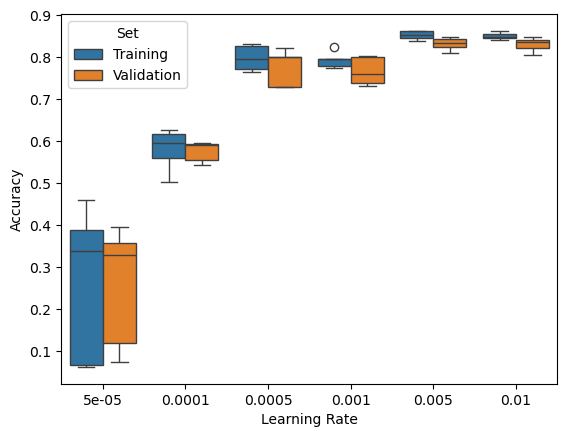

In [20]:
trainingDF = pd.DataFrame(train_accuracies, columns = ["0","1", "2","3","4"])
trainingDF["Learning Rate"] = learning_rates
trainingDF["Set"] = "Training"
valDF = pd.DataFrame(val_accuracies, columns = ["0","1", "2","3","4"])
valDF["Learning Rate"] = learning_rates
valDF["Set"] = "Validation"
completeSet = pd.concat([trainingDF.melt(value_vars = ["0","1","2","3","4"], var_name = "Fold", value_name = "Accuracy", id_vars=["Learning Rate","Set"]),valDF.melt(value_vars = ["0","1","2","3","4"], var_name = "Fold", value_name = "Accuracy", id_vars=["Learning Rate","Set"])])
completeSet = completeSet.reset_index()
sns.boxplot(data = completeSet, x = "Learning Rate", y = "Accuracy", hue = "Set", dodge = True)

### Architectures for batch normalization and dropout

In [25]:
class LinearCNN_2Filters_Dropout(nn.Module):
       
    def __init__(self, in_cs=1):
        super().__init__()
        self.conv = nn.ModuleList([
            nn.Conv1d(in_channels = 1, out_channels=2, kernel_size=4, stride=4, padding=0),
        ])
        self.activation = nn.ReLU()
        
        self.dropout = nn.Dropout(p=0.15)
        self.fc = nn.ModuleList([
            nn.Linear(136, 5), nn.Linear(5,1)])
    
    def forward(self, x):
        if x.ndim == 2:
            x = x.unsqueeze(1)
            
        for i in range(1):
            x = self.conv[i](x)
        x = nn.Flatten()(x)
        x = self.dropout(self.activation(self.fc[0](x)))
        x = self.fc[1](x)
        
        return x
    

class LinearCNN_2Filters_BatchNN(nn.Module):
       
    def __init__(self, in_cs=1):
        super().__init__()
        self.conv = nn.ModuleList([
            nn.Conv1d(in_channels = 1, out_channels=2, kernel_size=4, stride=4, padding=0),
        ])
        self.activation = nn.ReLU()
        self.bn = nn.ModuleList([nn.BatchNorm1d(2)])
        self.fc = nn.ModuleList([
            nn.Linear(136, 5), nn.Linear(5,1)])
    
    def forward(self, x):
        if x.ndim == 2:
            x = x.unsqueeze(1)
            
        for i in range(1):
            x = self.bn[i](self.conv[i](x))
        x = nn.Flatten()(x)
        x = self.activation(self.fc[0](x))
        x = self.fc[1](x)
        
        return x

In [27]:
trainDropoutAcc, valDropoutAcc = KFoldCrossValidationSaveRes(LinearCNN_2Filters_Dropout, 5, 
    X_1H_train, y_train, X_1H_test, y_test, 
    opt_method='adam', learning_rate=5e-3, batch_size=100, epoch=100, l2=0,
    early_break=False)
trainBatchNNAcc, valBatchNNAcc = KFoldCrossValidationSaveRes(LinearCNN_2Filters_BatchNN, 5, 
    X_1H_train, y_train, X_1H_test, y_test, 
    opt_method='adam', learning_rate=5e-3, batch_size=100, epoch=100, l2=0,
    early_break=False)

Fold 0:


Fold 1:


Fold 2:


Fold 3:


Fold 4:


In [32]:
l2_rates = [0, 1e-6, 5e-5, 1e-5, 5e-5, 1e-4]
trainl2_accuracies = []
vall2_accuracies = []
for i in l2_rates:
    trainAcc, valAcc = KFoldCrossValidationSaveRes(LinearCNN_2Filters, 5, 
    X_1H_train, y_train, X_1H_test, y_test, 
    opt_method='adam', learning_rate=5e-3, batch_size=100, epoch=100, l2=i,
    early_break=False)
    trainl2_accuracies.append(trainAcc)
    vall2_accuracies.append(valAcc)

Fold 0:


Fold 1:


Fold 2:


Fold 3:


Fold 4:


...

Fold 0:


Fold 1:


Fold 2:


Fold 3:


Fold 4:


<Axes: xlabel='Learning Rate', ylabel='Accuracy'>

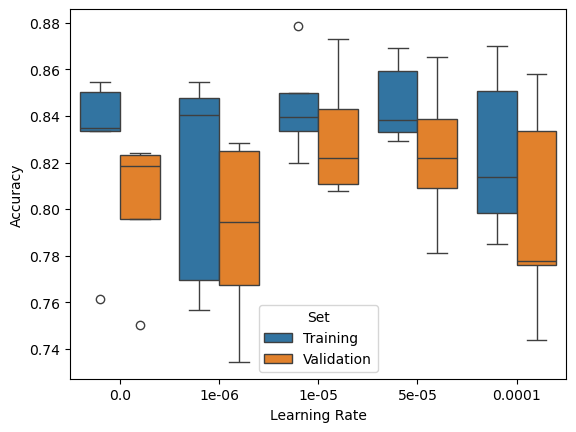

In [33]:
trainingL2DF = pd.DataFrame(trainl2_accuracies, columns = ["0","1", "2","3","4"])
trainingL2DF["Learning Rate"] = l2_rates
trainingL2DF["Set"] = "Training"
valL2DF = pd.DataFrame(vall2_accuracies, columns = ["0","1", "2","3","4"])
valL2DF["Learning Rate"] = l2_rates
valL2DF["Set"] = "Validation"
completeL2Set = pd.concat([trainingL2DF.melt(value_vars = ["0","1","2","3","4"], var_name = "Fold", value_name = "Accuracy", id_vars=["Learning Rate","Set"]),valL2DF.melt(value_vars = ["0","1","2","3","4"], var_name = "Fold", value_name = "Accuracy", id_vars=["Learning Rate","Set"])])
completeL2Set = completeL2Set.reset_index()
sns.boxplot(data = completeL2Set, x = "Learning Rate", y = "Accuracy", hue = "Set", dodge = True)

<Axes: xlabel='Regularization', ylabel='Accuracy'>

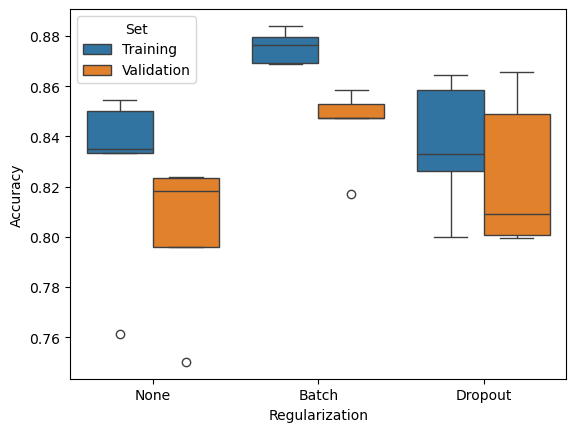

In [34]:
normalizationTraining = [trainl2_accuracies[0], trainBatchNNAcc, trainDropoutAcc]
normalizationValidation = [vall2_accuracies[0], valBatchNNAcc, valDropoutAcc]
normalizationTrainDF = pd.DataFrame(normalizationTraining, columns = ["0","1","2","3","4"])
normalizationTrainDF["Regularization"] = ["None","Batch","Dropout"]
normalizationTrainDF["Set"] = "Training"
normalizationValDF = pd.DataFrame(normalizationValidation, columns = ["0","1", "2","3","4"])
normalizationValDF["Regularization"] = ["None","Batch","Dropout"]
normalizationValDF["Set"] = "Validation"
completeNormalizationSet = pd.concat([normalizationTrainDF.melt(value_vars = ["0","1","2","3","4"], var_name = "Fold", value_name = "Accuracy", id_vars=["Regularization","Set"]),normalizationValDF.melt(value_vars = ["0","1","2","3","4"], var_name = "Fold", value_name = "Accuracy", id_vars=["Regularization","Set"])])
completeNormalizationSet = completeNormalizationSet.reset_index()
sns.boxplot(data = completeNormalizationSet, x = "Regularization", y = "Accuracy", hue = "Set", dodge = True)

### Final production

In [40]:
def KFoldCrossValidationSaveModel(
    model_class, k, 
    X_train, y_train, X_test, y_test, 
    opt_method='adam', learning_rate=2e-3, batch_size=128, epoch=50, l2=0.0,
    early_break=False,
    **model_args
):
    test_data = Cas13DataSet(torch.tensor(X_test, dtype=torch.float), torch.tensor(y_test, dtype=torch.float))
    kf = KFold(n_splits=k, shuffle=True)
    train_acc_list, test_acc_list = [], []
    best_model_state = None
    best_val_loss = float('inf')
    for i, (train_index, val_index) in enumerate(kf.split(X_train)):
        print(f"Fold {i}:")

        train_data = Cas13DataSet(torch.tensor(X_train[train_index], dtype=torch.float), torch.tensor(y_train[train_index], dtype=torch.float))
        val_data = Cas13DataSet(torch.tensor(X_train[val_index], dtype = torch.float), torch.tensor(y_train[val_index], dtype = torch.float))
        
        model = model_class(X_train.shape[1])
        
        trainer = Trainer(model, opt_method, learning_rate, batch_size, epoch, l2)
        res = trainer.train(train_data, val_data, draw_curve = True)
        train_acc_best = res['train_acc_list'][np.argmin(res['val_loss_list'])]
        test_loss, test_acc = trainer.evaluate(val_data)
        
        train_acc_list.append(train_acc_best)
        test_acc_list.append(test_acc)
        
        print(f"Training accuracy: {train_acc_best}")
        print(f"Validation accuracy: {test_acc}")
        
        if test_loss < best_val_loss:
            best_val_loss = test_loss
            best_model_state = model.state_dict().copy()
            
        if early_break:
            break
            
        torch.save(model.state_dict(), f"bestModelFold{i}.pth")
    
    if not early_break:
        print("Final results:")
        print(f"Training accuracy: {np.mean(train_acc_list)}+/-{np.std(train_acc_list)}")
        print(f"Test accuracy: {np.mean(test_acc_list)}+/-{np.std(test_acc_list)}")

Fold 0:


Training accuracy: 0.8867845526677101
Validation accuracy: 0.8455914383285617
Fold 1:


Training accuracy: 0.8801290027964216
Validation accuracy: 0.8482480462343415
Fold 2:


Training accuracy: 0.8870881609275636
Validation accuracy: 0.8452833504290195
Fold 3:


Training accuracy: 0.8826663667179457
Validation accuracy: 0.8548025106622195
Fold 4:


Training accuracy: 0.8893066362927777
Validation accuracy: 0.88112029543087
Final results:
Training accuracy: 0.8851949438804837+/-0.003318873390510533
Test accuracy: 0.8550091282170025+/-0.013496900459563465


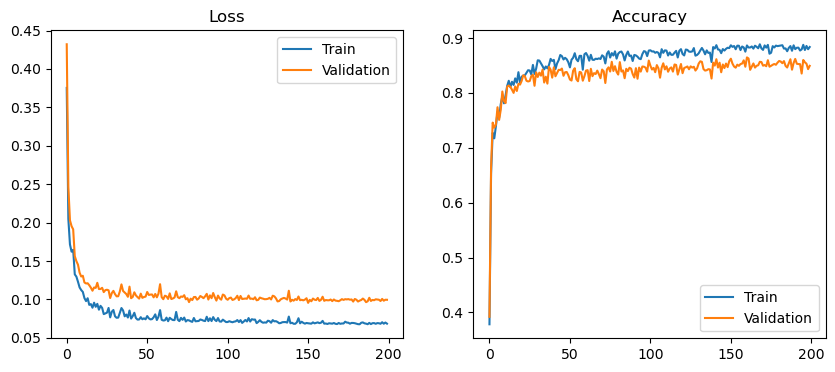

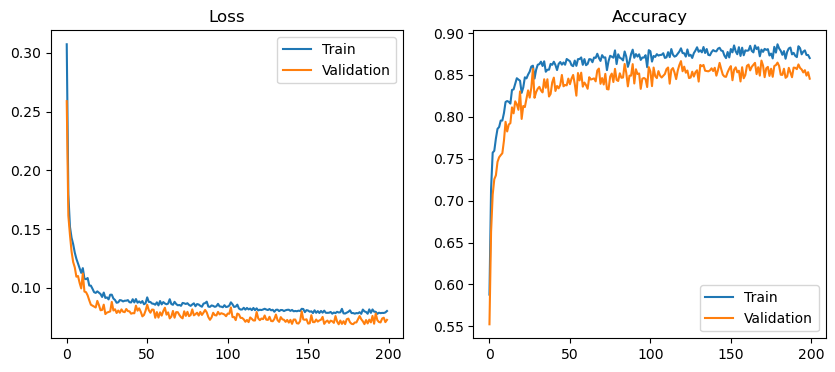

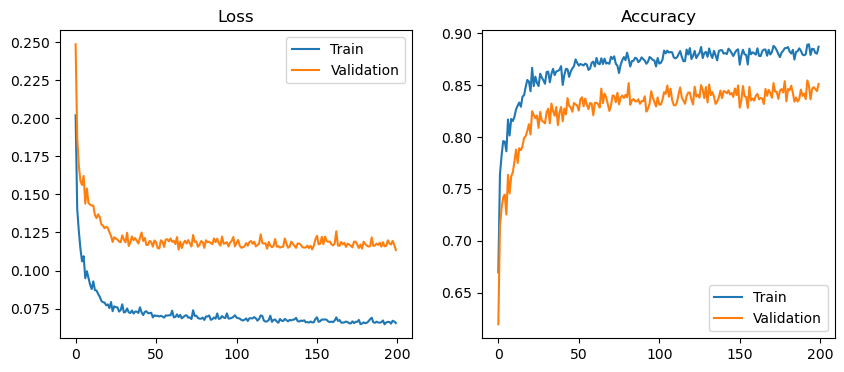

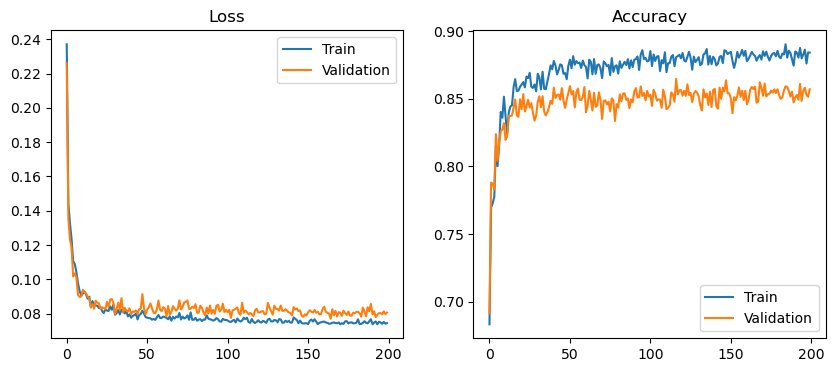

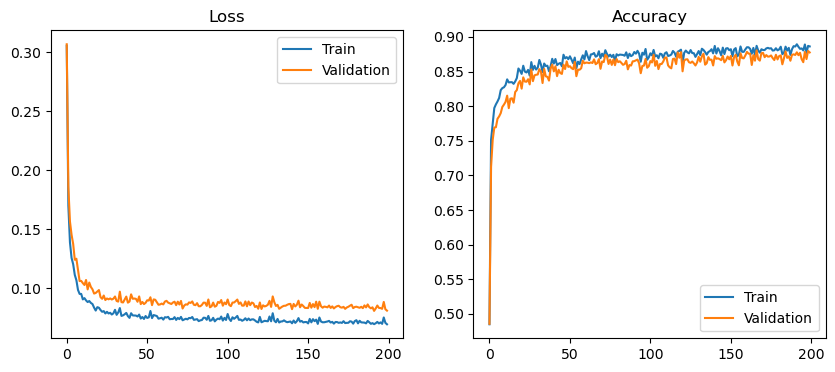

In [41]:
KFoldCrossValidationSaveModel(LinearCNN_2Filters_BatchNN, 5, 
    X_1H_train, y_train, X_1H_test, y_test, 
    opt_method='adam', learning_rate=5e-3, batch_size=100, epoch=200, l2=0,
    early_break=False)

In [114]:
FinalModel = LinearCNN_2Filters_BatchNN()
FinalModel.load_state_dict(torch.load('bestModelFold1.pth'))
FinalModel.eval()
with torch.no_grad():
    predictions = FinalModel(torch.tensor(X_1H_test, dtype = torch.float))

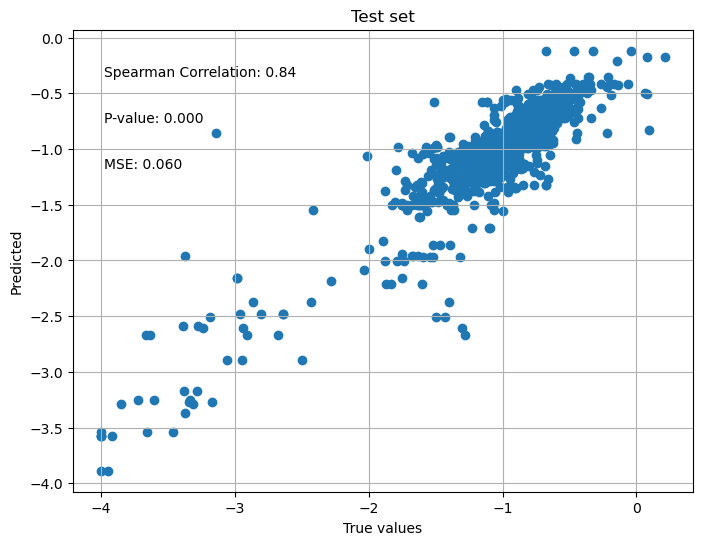

In [115]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions)
plt.xlabel("True values")
plt.ylabel("Predicted")
plt.title("Test set")

# Calculate Spearman correlation and p-value
correlation, p_value = spearmanr(y_test, predictions)
mse = mean_squared_error(y_test, predictions)

plt.text(
    0.05,
    0.9,
    f"Spearman Correlation: {correlation:.2f}",
    transform=plt.gca().transAxes,
)
plt.text(
    0.05,
    0.8,
    f"P-value: {p_value:.3f}",
    transform=plt.gca().transAxes,
)

plt.text(
    0.05,
    0.7,
    f"MSE: {mse:.3f}",
    transform=plt.gca().transAxes,
)



# Show the plot
plt.grid(True)
plt.show()